# Efficacité des méthodes d'assignation dans un scénario SMC

Objectif: comparer, sur **les mêmes particules**, le coût/qualité des méthodes d'assignation pour passer de l'itération `t` à `t+1`.

Protocole:
1. Générer un jeu de particules `(thetas_t, zs_t, sigma_t)` via `perm_abc_vanilla` (approximation de `pi_epsilon`).
2. Perturber `thetas_t` avec un **kernel de proposition** (`KernelTruncatedRW` / `KernelRW`, comme en SMC), en utilisant les assignations `ys_t`, `zs_t` et des poids uniformes pour les écarts-types RW, puis simuler `zs_t+1`.
3. Calculer `sigma_t+1` avec plusieurs méthodes.
4. Comparer à la référence **LSA optimale**:
   - temps de calcul,
   - distance moyenne,
   - ratio distance / distance LSA,
   - distance de Hamming de `sigma_t+1` à `sigma*_{LSA}`.

In [28]:
print("hello ")

hello 


In [29]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd()
for _ in range(4):
    if (ROOT / "permabc").is_dir():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from jax import random

try:
    import pandas as pd
except Exception:
    pd = None

from permabc.models.Gaussian_with_no_summary_stats import GaussianWithNoSummaryStats
from permabc.algorithms.vanilla import perm_abc_vanilla
from permabc.core.distances import (
    optimal_index_distance,
    compute_total_distance,
    compute_distances_with_current_assignment,
)
from permabc.core.lsa import solve_lsa
from permabc.core.hilbert import hilbert_distance

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
print("Python:", sys.executable)

Python: /Users/antoineluciano/.pyenv/versions/3.10.13/envs/permabc/bin/python


In [ ]:
# -------------------------
# Paramètres expérience
# -------------------------
SEED = 0
K = 100
N_PARTICLES = 10000
N_OBS = 100

# epsilon pour perm_abc_vanilla (pi_epsilon)
# Ajuste si besoin selon le temps de run.
EPSILON = np.inf

# Perturbation t -> t+1 : mêmes kernels que dans ABC-SMC (voir permabc.core.kernels)
from permabc.core.kernels import KernelRW, KernelTruncatedRW

# TRW respecte σ² ≥ 0 (support du modèle gaussien) ; KernelRW est RW additif brut.
KERNEL_CLASS = KernelTruncatedRW

key = random.PRNGKey(SEED)
model = GaussianWithNoSummaryStats(K=K, n_obs=N_OBS)


def _squeeze_non_particle_singletons(arr):
    a = np.asarray(arr)
    if a.ndim <= 1:
        return a
    axes = tuple(i for i in range(1, a.ndim) if a.shape[i] == 1)
    if axes:
        a = np.squeeze(a, axis=axes)
    return a


def normalize_zs(zs):
    z = _squeeze_non_particle_singletons(zs)
    # attendu: (N, K, d)
    if z.ndim == 2:
        z = z[:, :, None]
    return z


def normalize_theta_inplace(theta_obj):
    """Ramène `loc` à (N, K, d_loc) (corrige le cas vmap (N, K, K, d) comme pour `zs`)."""
    loc = np.asarray(_squeeze_non_particle_singletons(theta_obj.loc))
    while loc.ndim > 3:
        if loc.ndim == 4 and loc.shape[1] == loc.shape[2]:
            loc = np.diagonal(loc, axis1=1, axis2=2).transpose(0, 2, 1)
        elif loc.shape[1] == 1:
            loc = loc[:, 0]
        else:
            raise ValueError(f"thetas.loc: shape inattendue {loc.shape}")
    # (N, K, K) sans dimension d_loc explicite
    if loc.ndim == 3 and loc.shape[1] == loc.shape[2]:
        loc = np.diagonal(loc, axis1=1, axis2=2)
        if loc.ndim == 2:
            loc = loc[:, :, None]
    if loc.ndim == 2:
        loc = loc[:, :, None]
    theta_obj.loc = loc

    glob = np.asarray(_squeeze_non_particle_singletons(theta_obj.glob))
    if glob.ndim == 1:
        glob = glob[:, None]
    elif glob.ndim > 2:
        glob = glob.reshape(glob.shape[0], -1)[:, : model.dim_glob]
    theta_obj.glob = glob
    return theta_obj

# Observation y
key, k_prior, k_data = random.split(key, 3)
true_theta = model.prior_generator(k_prior, 1)
y_obs = normalize_zs(model.data_generator(k_data, true_theta))
if y_obs.ndim == 2:
    y_obs = y_obs[None, ...]

print(f"K={K}, N_particles={N_PARTICLES}, epsilon={EPSILON}")

K=100, N_particles=10000, epsilon=inf


: 

In [ ]:
# -------------------------
# 1) Particules à l'itération t depuis pi_epsilon (perm_abc_vanilla)
# -------------------------
key, k_van = random.split(key)
t0 = time.perf_counter()
zs_t, thetas_t, d_t, ys_t, zs_idx_t, n_sim_t = perm_abc_vanilla(
    key=k_van,
    model=model,
    n_points=N_PARTICLES,
    epsilon=EPSILON,
    y_obs=y_obs,
    assignment_method="lsa",  # référence pour construire pi_epsilon
)
t1 = time.perf_counter()

# Normalisation shapes pour éviter les axes singleton issus de vmap
def ensure_rank3_particles(arr, name):
    a = np.asarray(arr)
    # attendu final: (N, K, d)
    while a.ndim > 3:
        if a.ndim == 4 and a.shape[1] == a.shape[2]:
            # Cas observé avec perm_abc_vanilla: (N, K, K, d)
            # On garde la diagonale des deux axes K -> (N, K, d).
            a = np.diagonal(a, axis1=1, axis2=2).transpose(0, 2, 1)
        elif a.shape[1] == 1:
            a = a[:, 0]
        else:
            raise ValueError(f"{name}: shape inattendue {a.shape} (impossible de retirer proprement les singleton)")
    if a.ndim == 2:
        a = a[:, :, None]
    return a

zs_t = ensure_rank3_particles(zs_t, "zs_t")
thetas_t = normalize_theta_inplace(thetas_t)
y_obs = np.asarray(y_obs)
while y_obs.ndim > 3:
    if y_obs.shape[0] == 1:
        y_obs = y_obs[0]
    elif y_obs.shape[1] == 1:
        y_obs = y_obs[:, 0]
    else:
        raise ValueError(f"y_obs shape inattendue: {y_obs.shape}")
if y_obs.ndim == 2:
    y_obs = y_obs[None, ...]

print(f"perm_abc_vanilla done in {t1 - t0:.2f}s")
print(f"n_sim total: {int(n_sim_t)}, dist mean: {float(np.mean(d_t)):.4f}")
print("shapes:", np.asarray(zs_t).shape, np.asarray(thetas_t.loc).shape, np.asarray(thetas_t.glob).shape, np.asarray(y_obs).shape)

# sigma_t (référence à t)
t_perm0 = time.perf_counter()
dist_t_lsa, ys_t, zs_idx_t, _ = optimal_index_distance(
    model=model,
    zs=np.asarray(zs_t),
    y_obs=np.asarray(y_obs),
    epsilon=0.0,
    assignment_method="lsa",
    parallel=False,
)
perm_init_time_s = float(time.perf_counter() - t_perm0)
print(f"sigma_t computed. perm_init_time_s={perm_init_time_s:.2f}s")

Performing full optimal assignment (no prior indices).


In [ ]:
# -------------------------
# 2) Perturbation vers t+1 (kernels permabc, comme move_smc)
# -------------------------
# Poids uniformes → tau_loc / tau_glob = sqrt(2 * Var) sur les particules,
# avec μ permutés selon zs_idx_t (même logique que SMC).
weights = np.ones(N_PARTICLES, dtype=np.float64) / N_PARTICLES

proposal_kernel = KERNEL_CLASS(
    model=model,
    thetas=thetas_t,
    weights=weights,
    ys_index=np.asarray(ys_t, dtype=np.int32),
    zs_index=np.asarray(zs_idx_t, dtype=np.int32),
)

key, k_prop = random.split(key)
thetas_t1 = proposal_kernel.sample(k_prop)
thetas_t1 = normalize_theta_inplace(thetas_t1)

key, k_data_t1 = random.split(key)
zs_t1 = ensure_rank3_particles(model.data_generator(k_data_t1, thetas_t1), "zs_t1")

print(
    f"Perturbation ({KERNEL_CLASS.__name__}) | zs_t1 {np.asarray(zs_t1).shape} | "
    f"loc {np.asarray(thetas_t1.loc).shape} | glob {np.asarray(thetas_t1.glob).shape}"
)
print("tau_loc (par composante, avant expansion par particule):", np.asarray(proposal_kernel.tau_loc).squeeze())
print("tau_glob:", np.asarray(proposal_kernel.tau_glob).ravel())

Perturbation (KernelTruncatedRW) | zs_t1 (10000, 50, 100) | loc (10000, 50, 1) | glob (10000, 1)
tau_loc (par composante, avant expansion par particule): [1.8926588  1.31409785 1.33869519 2.06623746 1.45100702 1.60505383
 1.37693297 1.88389519 1.45154304 1.29207818 1.36060301 1.75493235
 1.33943523 1.39397765 1.42054352 1.28430481 2.41343296 1.54945151
 1.68096645 1.33996214 1.34424735 1.35037577 1.28956328 1.76290907
 1.31172233 2.08502621 1.51560026 1.66969937 2.41798787 1.5873152
 1.45610447 1.3129845  1.32228951 1.52756255 1.34323321 3.28954696
 1.31863503 1.41037849 1.28558159 1.35433384 1.29516653 1.55078222
 3.30410312 1.27850355 1.3603143  1.31796081 1.43067809 1.36053256
 1.30452718 1.42904555]
tau_glob: [4.86979274]


In [ ]:
# -------------------------
# 3) Benchmark méthodes d'assignation pour sigma_{t+1}
# -------------------------
def hamming_perm(z_idx, z_ref):
    z_idx = np.asarray(z_idx)
    z_ref = np.asarray(z_ref)
    if z_idx.shape != z_ref.shape:
        n = min(z_idx.shape[1], z_ref.shape[1])
        z_idx = z_idx[:, :n]
        z_ref = z_ref[:, :n]
    return float(np.mean(np.mean(z_idx != z_ref, axis=1)))


def _swap_refine_from_init(model, zs, y_obs, ys_init, zs_init, max_sweeps=2):
    """WarmStart + Swap: start from sigma_t then greedy swaps."""
    ys = np.asarray(ys_init).copy().astype(np.int32)
    zs_idx = np.asarray(zs_init).copy().astype(np.int32)
    local = np.asarray(model.distance_matrices_loc(np.asarray(zs), np.asarray(y_obs), M=model.K, L=model.K))
    global_d = np.asarray(model.distance_global(np.asarray(zs), np.asarray(y_obs)))

    n, k = ys.shape
    for p in range(n):
        y = ys[p]
        z = zs_idx[p]
        c = local[p]
        for _ in range(max_sweeps):
            changed = False
            for i in range(k - 1):
                yi, zi = int(y[i]), int(z[i])
                for j in range(i + 1, k):
                    yj, zj = int(y[j]), int(z[j])
                    old = c[yi, zi] + c[yj, zj]
                    new = c[yi, zj] + c[yj, zi]
                    if new < old:
                        z[i], z[j] = z[j], z[i]
                        zi = int(z[i])
                        changed = True
            if not changed:
                break
        zs_idx[p] = z

    d = np.sqrt(np.array([local[p, ys[p], zs_idx[p]].sum() + global_d[p] for p in range(n)], dtype=float))
    return d, ys, zs_idx


def run_assignment(method, warmstart=False):
    zs1 = np.asarray(zs_t1)
    yobs = np.asarray(y_obs)
    if yobs.ndim == 2:
        yobs = yobs[None, ...]

    N = zs1.shape[0]
    K = model.K
    M = model.K
    L = model.K

    weights = np.asarray(model.weights_distance[:K], dtype=float)
    y_ref = yobs[0, :K]

    def _swap_refine_assignments(local_mats, ys_idx, zs_idx, max_sweeps=2):
        ys_out = np.asarray(ys_idx, dtype=np.int32).copy()
        zs_out = np.asarray(zs_idx, dtype=np.int32).copy()
        n, k = ys_out.shape
        for p in range(n):
            y = ys_out[p]
            z = zs_out[p]
            c = local_mats[p]
            for _ in range(max_sweeps):
                changed = False
                for i in range(k - 1):
                    yi, zi = int(y[i]), int(z[i])
                    for j in range(i + 1, k):
                        yj, zj = int(y[j]), int(z[j])
                        old = c[yi, zi] + c[yj, zj]
                        new = c[yi, zj] + c[yj, zi]
                        if new < old:
                            z[i], z[j] = z[j], z[i]
                            zi = int(z[i])
                            changed = True
                if not changed:
                    break
            zs_out[p] = z
        return ys_out.astype(np.int32), zs_out.astype(np.int32)

    if method == "warmstart_identity":
        # Sigma_t impose: permutation = (ys_t, zs_idx_t), pas de re-optimisation.
        t_total0 = time.perf_counter()

        ys = np.asarray(ys_t).copy().astype(np.int32)
        zs_idx = np.asarray(zs_idx_t).copy().astype(np.int32)

        t_m0 = time.perf_counter()
        local = np.asarray(model.distance_matrices_loc(zs1, yobs, M=M, L=L))
        local = np.where(np.isinf(local), 1e12, local)
        dt_m = time.perf_counter() - t_m0

        t_g0 = time.perf_counter()
        global_d = np.asarray(model.distance_global(zs1, yobs))
        dt_g = time.perf_counter() - t_g0

        t_e0 = time.perf_counter()
        d = compute_total_distance(zs_idx, ys, local, global_d)
        d = np.asarray(d)
        dt_e = time.perf_counter() - t_e0

        dt_total = time.perf_counter() - t_total0
        return {
            "distance": d,
            "ys": ys,
            "zs": zs_idx,
            "n_ops": 0,
            "time": float(dt_total),
            "time_matrices_s": float(dt_m),
            "time_global_s": float(dt_g),
            "time_opt_approx_s": 0.0,
            "time_eval_s": float(dt_e),
            "time_pre_eval_s": 0.0,
        }

    if method == "warmstart_swap":
        # WarmStart + Swap: on part de (ys_t, zs_idx_t) puis on affîne uniquement zs via swaps.
        t_total0 = time.perf_counter()

        ys = np.asarray(ys_t).copy().astype(np.int32)
        zs_idx = np.asarray(zs_idx_t).copy().astype(np.int32)

        t_m0 = time.perf_counter()
        local = np.asarray(model.distance_matrices_loc(zs1, yobs, M=M, L=L))
        local = np.where(np.isinf(local), 1e12, local)
        dt_m = time.perf_counter() - t_m0

        t_g0 = time.perf_counter()
        global_d = np.asarray(model.distance_global(zs1, yobs))
        dt_g = time.perf_counter() - t_g0

        t_opt0 = time.perf_counter()
        ys_ref, zs_ref = _swap_refine_assignments(local, ys, zs_idx, max_sweeps=2)
        dt_opt = time.perf_counter() - t_opt0

        t_e0 = time.perf_counter()
        d = compute_total_distance(zs_ref, ys_ref, local, global_d)
        d = np.asarray(d)
        dt_e = time.perf_counter() - t_e0

        dt_total = time.perf_counter() - t_total0
        return {
            "distance": d,
            "ys": ys_ref,
            "zs": zs_ref,
            "n_ops": int(N),
            "time": float(dt_total),
            "time_matrices_s": float(dt_m),
            "time_global_s": float(dt_g),
            "time_opt_approx_s": float(dt_opt),
            "time_eval_s": float(dt_e),
            "time_pre_eval_s": 0.0,
        }

    if method == "lsa":
        if not warmstart:
            t_total0 = time.perf_counter()

            t_m0 = time.perf_counter()
            local = np.asarray(model.distance_matrices_loc(zs1, yobs, M=M, L=L))
            local = np.where(np.isinf(local), 1e12, local)
            dt_m = time.perf_counter() - t_m0

            t_g0 = time.perf_counter()
            global_d = np.asarray(model.distance_global(zs1, yobs))
            dt_g = time.perf_counter() - t_g0

            t_opt0 = time.perf_counter()
            ys_idx, zs_idx = solve_lsa(local, parallel=False)
            dt_opt = time.perf_counter() - t_opt0

            t_e0 = time.perf_counter()
            d = compute_total_distance(zs_idx, ys_idx, local, global_d)
            d = np.asarray(d)
            dt_e = time.perf_counter() - t_e0

            dt_total = time.perf_counter() - t_total0
            return {
                "distance": d,
                "ys": ys_idx,
                "zs": zs_idx,
                "n_ops": int(N),
                "time": float(dt_total),
                "time_matrices_s": float(dt_m),
                "time_global_s": float(dt_g),
                "time_opt_approx_s": float(dt_opt),
                "time_eval_s": float(dt_e),
                "time_pre_eval_s": 0.0,
            }

        # warmstart=True: smart-accept (mais epsilon=0 => potentiellement tout).
        epsilon = 0.0

        t_total0 = time.perf_counter()

        ys_init = np.asarray(ys_t).copy().astype(np.int32)
        zs_init = np.asarray(zs_idx_t).copy().astype(np.int32)

        t_pre0 = time.perf_counter()
        current_distances = compute_distances_with_current_assignment(
            model=model,
            zs=zs1,
            y_obs=yobs,
            ys_index=ys_init,
            zs_index=zs_init,
            M=M,
            L=L,
        )
        current_distances = np.asarray(current_distances)
        dt_pre = time.perf_counter() - t_pre0

        particles_to_reassign = np.where(current_distances >= epsilon)[0]
        n_lsa = int(len(particles_to_reassign))

        if n_lsa == 0:
            dt_total = time.perf_counter() - t_total0
            return {
                "distance": current_distances,
                "ys": ys_init,
                "zs": zs_init,
                "n_ops": 0,
                "time": float(dt_total),
                "time_matrices_s": 0.0,
                "time_global_s": 0.0,
                "time_opt_approx_s": 0.0,
                "time_eval_s": 0.0,
                "time_pre_eval_s": float(dt_pre),
            }

        zs_subset = zs1[particles_to_reassign]

        t_m0 = time.perf_counter()
        local_subset = np.asarray(model.distance_matrices_loc(zs_subset, yobs, M=M, L=L))
        local_subset = np.where(np.isinf(local_subset), 1e12, local_subset)
        dt_m = time.perf_counter() - t_m0

        t_g0 = time.perf_counter()
        global_subset = np.asarray(model.distance_global(zs_subset, yobs))
        dt_g = time.perf_counter() - t_g0

        t_opt0 = time.perf_counter()
        ys_idx_sub, zs_idx_sub = solve_lsa(local_subset, parallel=False)
        dt_opt = time.perf_counter() - t_opt0

        t_e0 = time.perf_counter()
        d_sub = compute_total_distance(zs_idx_sub, ys_idx_sub, local_subset, global_subset)
        d_sub = np.asarray(d_sub)
        dt_e = time.perf_counter() - t_e0

        optimal_distances = current_distances.copy()
        optimal_distances[particles_to_reassign] = d_sub

        ys_out = ys_init.copy()
        zs_out = zs_init.copy()
        ys_out[particles_to_reassign] = ys_idx_sub
        zs_out[particles_to_reassign] = zs_idx_sub

        dt_total = time.perf_counter() - t_total0
        return {
            "distance": optimal_distances,
            "ys": ys_out,
            "zs": zs_out,
            "n_ops": n_lsa,
            "time": float(dt_total),
            "time_matrices_s": float(dt_m),
            "time_global_s": float(dt_g),
            "time_opt_approx_s": float(dt_opt),
            "time_eval_s": float(dt_e),
            "time_pre_eval_s": float(dt_pre),
        }

    if method == "hilbert":
        t_total0 = time.perf_counter()

        t_g0 = time.perf_counter()
        global_d = np.asarray(model.distance_global(zs1, yobs))
        dt_g = time.perf_counter() - t_g0

        t_opt0 = time.perf_counter()
        hilbert_dist, ys_idx, zs_idx = hilbert_distance(
            zs=zs1[:, :M],
            y_ref=y_ref,
            weights=weights,
            n_bits=12,
        )
        dt_opt = time.perf_counter() - t_opt0

        t_e0 = time.perf_counter()
        d = np.sqrt(np.asarray(hilbert_dist) ** 2 + global_d)
        dt_e = time.perf_counter() - t_e0

        dt_total = time.perf_counter() - t_total0
        return {
            "distance": d,
            "ys": ys_idx,
            "zs": zs_idx,
            "n_ops": int(N),
            "time": float(dt_total),
            "time_matrices_s": 0.0,
            "time_global_s": float(dt_g),
            "time_opt_approx_s": float(dt_opt),
            "time_eval_s": float(dt_e),
            "time_pre_eval_s": 0.0,
        }

    if method == "hilbert_swap":
        t_total0 = time.perf_counter()

        t_g0 = time.perf_counter()
        global_d = np.asarray(model.distance_global(zs1, yobs))
        dt_g = time.perf_counter() - t_g0

        t_opt0 = time.perf_counter()
        hilbert_dist, ys_idx, zs_idx = hilbert_distance(
            zs=zs1[:, :M],
            y_ref=y_ref,
            weights=weights,
            n_bits=12,
        )
        dt_hilbert = time.perf_counter() - t_opt0

        t_m0 = time.perf_counter()
        local = np.asarray(model.distance_matrices_loc(zs1, yobs, M=M, L=L))
        local = np.where(np.isinf(local), 1e12, local)
        dt_m = time.perf_counter() - t_m0

        t_swap0 = time.perf_counter()
        ys_ref, zs_ref = _swap_refine_assignments(local, ys_idx, zs_idx, max_sweeps=2)
        dt_swap = time.perf_counter() - t_swap0

        t_e0 = time.perf_counter()
        d = compute_total_distance(zs_ref, ys_ref, local, global_d)
        d = np.asarray(d)
        dt_e = time.perf_counter() - t_e0

        dt_total = time.perf_counter() - t_total0
        return {
            "distance": d,
            "ys": ys_ref,
            "zs": zs_ref,
            "n_ops": int(N),
            "time": float(dt_total),
            "time_matrices_s": float(dt_m),
            "time_global_s": float(dt_g),
            "time_opt_approx_s": float(dt_hilbert + dt_swap),
            "time_eval_s": float(dt_e),
            "time_pre_eval_s": 0.0,
        }

    raise ValueError(f"Unknown method={method!r}")

# Référence optimale LSA à t+1
ref = run_assignment("lsa", warmstart=False)

bench_cfg = [
    ("lsa", False, "LSA"),
    ("hilbert", False, "Hilbert"),
    ("hilbert_swap", False, "Hilbert+Swap"),
    ("lsa", True, "LSA warm-start"),
    ("warmstart_identity", True, "WarmStart direct (sigma_t)"),
    ("warmstart_swap", True, "WarmStart+Swap (sigma_t + swaps)"),
]

rows = []
for method, warm, label in bench_cfg:
    out = run_assignment(method, warmstart=warm)
    dist_mean = float(np.mean(out["distance"]))
    dist_ratio = dist_mean / float(np.mean(ref["distance"]))
    h = hamming_perm(out["zs"], ref["zs"])
    rows.append({
        "method": label,
        "time_s": out["time"],
        "perm_init_time_s": perm_init_time_s,
        "mean_distance": dist_mean,
        "distance_ratio_vs_lsa": dist_ratio,
        "hamming_vs_lsa": h,
        "n_particles_recomputed": out["n_ops"],
        "time_matrices_s": out.get("time_matrices_s", 0.0),
        "time_global_s": out.get("time_global_s", 0.0),
        "time_opt_approx_s": out.get("time_opt_approx_s", 0.0),
        "time_eval_s": out.get("time_eval_s", 0.0),
        "time_pre_eval_s": out.get("time_pre_eval_s", 0.0),
    })

if pd is not None:
    df = pd.DataFrame(rows).sort_values("time_s")
    display(df)
else:
    for r in sorted(rows, key=lambda x: x["time_s"]):
        print(r)

df_rows = rows  # fallback pour plotting

,method,time_s,perm_init_time_s,mean_distance,distance_ratio_vs_lsa,hamming_vs_lsa,n_particles_recomputed,time_matrices_s,time_global_s,time_opt_approx_s,time_eval_s,time_pre_eval_s
1,Hilbert,9.215281,59.165354,6.832306,1.250905,0.982366,10000,0.000000,0.001148,9.214104,0.000027,0.000000
3,LSA warm-start,63.316102,59.165354,5.461892,1.000000,0.000000,10000,60.756709,0.003160,1.012867,0.329507,1.169336
4,WarmStart direct (sigma_t),65.571442,59.165354,5.869516,1.074630,0.872292,0,65.158240,0.002097,0.000000,0.403567,0.000000
0,LSA,71.485682,59.165354,5.461892,1.000000,0.000000,10000,70.179294,0.001093,0.954891,0.350396,0.000000
2,Hilbert+Swap,76.648328,59.165354,5.473063,1.002045,0.960196,10000,56.804012,0.000953,19.722950,0.120400,0.000000
5,WarmStart+Swap (sigma_t + swaps),84.949759,59.165354,5.465252,1.000615,0.208390,10000,70.214880,0.002033,14.462293,0.263809,0.000000


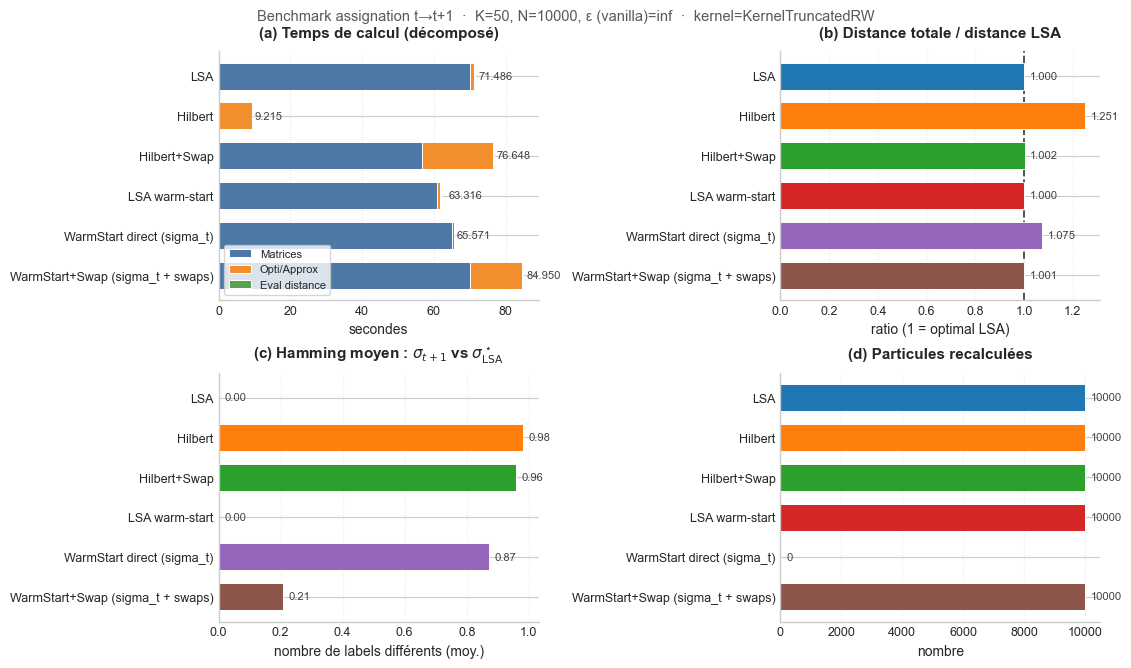

In [ ]:
# -------------------------
# 4) Plots synthèse
# -------------------------
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass

labels = [r["method"] for r in df_rows]
times = np.asarray([r["time_s"] for r in df_rows], dtype=float)
ratios = np.asarray([r["distance_ratio_vs_lsa"] for r in df_rows], dtype=float)
hamming = np.asarray([r["hamming_vs_lsa"] for r in df_rows], dtype=float)
n_recomp = np.asarray([r["n_particles_recomputed"] for r in df_rows], dtype=float)

time_m = np.asarray([r.get("time_matrices_s", 0.0) for r in df_rows], dtype=float)
time_opt = np.asarray([r.get("time_opt_approx_s", 0.0) for r in df_rows], dtype=float)
time_eval = np.asarray([r.get("time_eval_s", 0.0) for r in df_rows], dtype=float)

y = np.arange(len(labels))
cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(len(labels))]


def _barh_panel(ax, values, title, xlabel, *, ref_line=None, bar_fmt=None):
    bars = ax.barh(
        y,
        values,
        color=colors,
        edgecolor="white",
        linewidth=0.7,
        height=0.68,
        zorder=2,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, fontweight="semibold", pad=10)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.4, linestyle=":", linewidth=0.9, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ref_line is not None:
        ax.axvline(
            ref_line,
            color="0.25",
            linestyle="--",
            linewidth=1.4,
            zorder=1,
            alpha=0.9,
        )
    if bar_fmt is not None:
        ax.bar_label(bars, fmt=bar_fmt, padding=4, fontsize=8, color="0.25")


fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.4), layout="constrained")
fig.suptitle(
    f"Benchmark assignation t→t+1  ·  K={K}, N={N_PARTICLES}, ε (vanilla)={EPSILON}  ·  kernel={KERNEL_CLASS.__name__}",
    fontsize=10.5,
    color="0.35",
    y=1.02,
)

# (a) Décomposition du temps: matrices + opti/approx + évaluation distance
ax = axes[0, 0]
bars_m = ax.barh(y, time_m, color="#4E79A7", edgecolor="white", linewidth=0.7, height=0.68, zorder=2, label="Matrices")
bars_o = ax.barh(y, time_opt, left=time_m, color="#F28E2B", edgecolor="white", linewidth=0.7, height=0.68, zorder=2, label="Opti/Approx")
bars_e = ax.barh(y, time_eval, left=time_m + time_opt, color="#59A14F", edgecolor="white", linewidth=0.7, height=0.68, zorder=2, label="Eval distance")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_title("(a) Temps de calcul (décomposé)", fontsize=11, fontweight="semibold", pad=10)
ax.set_xlabel("secondes")
ax.grid(True, axis="x", alpha=0.4, linestyle=":", linewidth=0.9, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower left", fontsize=8, frameon=True)

# Affiche le temps total à droite de chaque barre empilée
for yi, total in enumerate(times):
    ax.text(total + 0.01 * max(times.max(), 1.0), yi, f"{total:.3f}", va="center", ha="left", fontsize=8, color="0.25")
_barh_panel(
    axes[0, 1],
    ratios,
    "(b) Distance totale / distance LSA",
    "ratio (1 = optimal LSA)",
    ref_line=1.0,
    bar_fmt="%.3f",
)
_barh_panel(
    axes[1, 0],
    hamming,
    r"(c) Hamming moyen : $\sigma_{t+1}$ vs $\sigma_{\mathrm{LSA}}^\star$",
    "nombre de labels différents (moy.)",
    bar_fmt="%.2f",
)
_barh_panel(axes[1, 1], n_recomp, "(d) Particules recalculées", "nombre", bar_fmt="%.0f")

plt.show()

## Notes d'interprétation

- `distance_ratio_vs_lsa > 1` : approximation moins précise que LSA.
- `hamming_vs_lsa` proche de 0 : permutation proche de l'optimum LSA.
- `warm-start` peut réduire fortement le coût si les perturbations `t -> t+1` sont modérées.
- Pour stress-test, utilise `KernelRW` (RW non tronqué sur σ²) ou réduis la diversité des particules à `t` (ε plus petit) pour des `tau` plus petits ; tu peux aussi passer des `tau_loc_glob` fixés au constructeur du kernel si besoin d’échelle contrôlée.
- Pour le régime SMC réaliste, répéter pour plusieurs seeds et reporter moyenne ± écart-type.